In [147]:
import copy
import os
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
from pathlib import Path
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader

In [148]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 20269999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps'):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, 'manual_seed') else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Global seed fixed: {SEED}')

Global seed fixed: 20269999


In [149]:
# ── Config ────────────────────────────────────────────────────────────────────
TRAIN_CUTOFF     = '2025-01'
NEIGHBOR_RADIUS  = 1
FOCAL_OUT_WEIGHT = 0.0
NUM_EPOCHS       = 200
BATCH_SIZE       = 8
LEARNING_RATE    = 1e-4
FREEZE_EPOCHS    = 30
UNFREEZE_LR      = 1e-5

In [150]:
# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parents[0]
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUT_DIR      = MODELS_DIR / 'focal_mask_all_features'
OUT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_PATH     = OUT_DIR / 'weights.pt'
PREDICTIONS_PATH = OUT_DIR / 'predictions.csv'
FOCAL_MASK_PATH  = MODELS_DIR / f'focal_mask_r{NEIGHBOR_RADIUS}.npy'
IMPORTANCE_PATH  = OUT_DIR / 'feature_importance.csv'
print(f'OUT_DIR: {OUT_DIR}')

OUT_DIR: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features


In [151]:
# ── Load data ─────────────────────────────────────────────────────────────────
target = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target['year_month'] = target['year_month'].astype(str)
print(f'Target rows: {len(target):,}  |  months: {target["year_month"].nunique()}'
      f'  |  cells: {target["priogrid_gid"].nunique()}')
print('\nClass distribution:')
print(target['target'].value_counts())

features = pd.read_csv(DATA_PROC / 'myanmar_feature_store.csv')
features['year_month'] = features['year_month'].astype(str)

Target rows: 5,238  |  months: 29  |  cells: 185

Class distribution:
target
gov          3303
opo          1110
uncertain     825
Name: count, dtype: int64


In [152]:
# ── Dynamic feature selection ─────────────────────────────────────────────────
# Exclude identifiers, datetime strings, and categorical columns
EXCLUDE_COLS   = {'priogrid_gid', 'year_month', 'year_month_dt', 'adm_1'}
INPUT_FEATURES = [c for c in features.columns if c not in EXCLUDE_COLS]
NUM_CHANNELS   = len(INPUT_FEATURES)
print(f'Input features ({NUM_CHANNELS}):')
for i, f in enumerate(INPUT_FEATURES):
    print(f'  [{i:2d}] {f}')

Input features (93):
  [ 0] total_events
  [ 1] is_statebased
  [ 2] is_onesided
  [ 3] gov_vs_civilians
  [ 4] total_fatalities
  [ 5] deaths_a
  [ 6] deaths_b
  [ 7] deaths_civilians
  [ 8] events_gov
  [ 9] events_nug
  [10] events_kio
  [11] events_ula
  [12] events_knu
  [13] events_mndaa
  [14] events_pslf
  [15] events_cnf
  [16] events_rcss
  [17] events_uwsa
  [18] n_unique_dyads
  [19] total_events_lag1
  [20] total_fatalities_lag1
  [21] events_gov_lag1
  [22] events_nug_lag1
  [23] gov_vs_civilians_lag1
  [24] is_onesided_lag1
  [25] total_events_lag3
  [26] total_fatalities_lag3
  [27] events_gov_lag3
  [28] events_nug_lag3
  [29] gov_vs_civilians_lag3
  [30] is_onesided_lag3
  [31] total_events_lag6
  [32] total_fatalities_lag6
  [33] events_gov_lag6
  [34] events_nug_lag6
  [35] gov_vs_civilians_lag6
  [36] is_onesided_lag6
  [37] total_events_roll3m
  [38] total_fatalities_roll3m
  [39] total_events_roll6m
  [40] total_fatalities_roll6m
  [41] gov_event_share
  [42] nug

In [153]:
# ── Raster construction ───────────────────────────────────────────────────────
LABEL_MAP   = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL   = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['gov', 'opo', 'uncertain']


def gid_to_rowcol(gid):
    return (gid - 1) // 720, (gid - 1) % 720


all_gids   = features['priogrid_gid'].unique()
gid_coords = {}
for gid in all_gids:
    r, c = gid_to_rowcol(gid)
    gid_coords[gid] = {'global_row': r, 'global_col': c}
coords_df = pd.DataFrame.from_dict(gid_coords, orient='index')
coords_df.index.name = 'priogrid_gid'

min_global_row = coords_df['global_row'].min()
min_global_col = coords_df['global_col'].min()
coords_df['local_row'] = coords_df['global_row'] - min_global_row
coords_df['local_col'] = coords_df['global_col'] - min_global_col

RASTER_H = coords_df['local_row'].max() + 1
RASTER_W = coords_df['local_col'].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

gid_to_local = coords_df[['local_row', 'local_col']].to_dict('index')

# Left join: recovers zero-event cells with Wikipedia annotations
labelled = target[['priogrid_gid', 'year_month', 'target']].merge(
    features, on=['priogrid_gid', 'year_month'], how='left'
)
labelled[INPUT_FEATURES] = labelled[INPUT_FEATURES].fillna(0.0)
labelled['label_int'] = labelled['target'].map(LABEL_MAP)

for gid in labelled['priogrid_gid'].unique():
    if gid in gid_to_local:
        continue
    r0, c0 = gid_to_rowcol(gid)
    lr = r0 - min_global_row
    lc = c0 - min_global_col
    if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
        gid_to_local[gid] = {'local_row': lr, 'local_col': lc}

n_recovered = len(labelled['priogrid_gid'].unique()) - len(all_gids)
print(f'Left join: {labelled["priogrid_gid"].nunique()} unique cells'
      f'  ({n_recovered:+d} vs inner-join baseline)')

Left join: 185 unique cells  (-14 vs inner-join baseline)


In [154]:
# ── Normalisation ─────────────────────────────────────────────────────────────
train_mask_rows   = labelled['year_month'] <= TRAIN_CUTOFF
train_months_used = sorted(labelled.loc[train_mask_rows, 'year_month'].unique())
feat_means = labelled.loc[train_mask_rows, INPUT_FEATURES].mean()
feat_stds  = labelled.loc[train_mask_rows, INPUT_FEATURES].std().replace(0, 1)
print(f'Normalisation fit on {len(train_months_used)} training months: '
      f'{train_months_used[0]} → {train_months_used[-1]}')
labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

Normalisation fit on 15 training months: 2023-11 → 2025-01


In [155]:
# ── Build raster arrays ───────────────────────────────────────────────────────
months_with_labels = sorted(labelled['year_month'].unique())
X_rasters, y_rasters, masks_r, month_keys = [], [], [], []

for month in months_with_labels:
    md_ = labelled[labelled['year_month'] == month]
    X_r = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
    y_r = np.full((PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
    msk = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local:
            continue
        lr, lc         = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[INPUT_FEATURES].values
        y_r[lr, lc]    = row['label_int']
        msk[lr, lc]    = 1
    X_rasters.append(np.transpose(X_r, (2, 0, 1)))
    y_rasters.append(y_r)
    masks_r.append(msk)
    month_keys.append(month)

X_array = np.stack(X_rasters)
y_array = np.stack(y_rasters)
m_array = np.stack(masks_r)

train_idx = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]
X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]

print(f'Raster shape: {X_array.shape}  (months x channels x H x W)')
print(f'Train months: {len(train_idx)}  ({month_keys[train_idx[0]]} → {month_keys[train_idx[-1]]})')
print(f'Val   months: {len(val_idx)}   ({month_keys[val_idx[0]]} → {month_keys[val_idx[-1]]})')

Raster shape: (29, 93, 40, 16)  (months x channels x H x W)
Train months: 15  (2023-11 → 2025-01)
Val   months: 14   (2025-02 → 2026-03)


In [156]:
# ── Focal mask ────────────────────────────────────────────────────────────────
label_by_gid  = labelled.groupby('priogrid_gid')['label_int'].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster[lr, lc] = True

struct        = np.ones((2 * NEIGHBOR_RADIUS + 1, 2 * NEIGHBOR_RADIUS + 1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)

np.save(FOCAL_MASK_PATH, focal_mask_np)
print(f'Focal mask saved: {FOCAL_MASK_PATH}'
      f'  ({focal_mask_np.sum()} focal pixels, {len(changing_gids)} changing cells)')

Focal mask saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_r1.npy  (285 focal pixels, 94 changing cells)


In [157]:
# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


In [158]:
# ── Model and loss ────────────────────────────────────────────────────────────
NUM_CLASSES     = 3
ENCODER_NAME    = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

label_counts         = np.array([
    (labelled['label_int'] == 0).sum(),
    (labelled['label_int'] == 1).sum(),
    (labelled['label_int'] == 2).sum(),
])
class_weights_np     = len(labelled) / (NUM_CLASSES * label_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

dice_loss_fn      = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)
focal_mask_tensor = torch.from_numpy(focal_mask_np).bool().to(DEVICE)


def combined_loss(predictions, targets, mask):
    safe_targets = targets.clone()
    safe_targets[mask == 0] = 0
    preds_hwc   = predictions.permute(0, 2, 3, 1)
    valid_preds = preds_hwc[mask == 1]
    valid_tgts  = targets[mask == 1]
    if valid_preds.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=predictions.device)
    ce = F.cross_entropy(valid_preds, valid_tgts, weight=class_weights_tensor)
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


def focal_combined_loss(predictions, targets, label_mask):
    B           = predictions.shape[0]
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)
    pixel_w     = torch.where(
        focal_broad,
        label_mask.float(),
        label_mask.float() * FOCAL_OUT_WEIGHT,
    )
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0
    ce_per_pixel = F.cross_entropy(
        predictions, safe_targets,
        weight=class_weights_tensor,
        reduction='none',
    )
    n_effective = pixel_w.sum() + 1e-8
    ce = (ce_per_pixel * pixel_w).sum() / n_effective
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


def build_model():
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    return smp.Unet(
        encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
        in_channels=NUM_CHANNELS,  classes=NUM_CLASSES,
        activation=None, decoder_channels=(128, 64, 32, 16), encoder_depth=4,
    ).to(DEVICE)


def build_optimizer(model):
    params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt    = optim.Adam(params, lr=LEARNING_RATE, weight_decay=1e-5)
    sch    = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    return opt, sch

In [159]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.mask    = mask.astype(np.uint8)
        self.augment = augment
        self.T       = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X, y, mask = (torch.from_numpy(self.X[idx]),
                      torch.from_numpy(self.y[idx]),
                      torch.from_numpy(self.mask[idx]))
        if self.augment:
            if torch.rand(1).item() > 0.5:
                X, y, mask = torch.flip(X, [2]), torch.flip(y, [1]), torch.flip(mask, [1])
            if torch.rand(1).item() > 0.7:
                X, y, mask = torch.flip(X, [1]), torch.flip(y, [0]), torch.flip(mask, [0])
            X = X + torch.randn_like(X) * 0.05
        return X, y, mask


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loaders():
    g        = torch.Generator(); g.manual_seed(SEED)
    train_ds = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_ds   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    tr_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, drop_last=False,
                       generator=g, worker_init_fn=seed_worker)
    va_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_ld, va_ld


def compute_metrics(logits, targets, mask):
    preds   = torch.argmax(logits, dim=1)
    vp, vt  = preds[mask == 1], targets[mask == 1]
    if len(vt) == 0:
        return {'overall_acc': 0.0}
    acc     = (vp == vt).float().mean().item()
    cls_acc = {}
    for c, name in enumerate(CLASS_NAMES):
        cm = vt == c
        cls_acc[name] = (vp[cm] == c).float().mean().item() if cm.sum() > 0 else float('nan')
    return {'overall_acc': acc, **cls_acc}


def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False


def unfreeze_encoder(model, optimizer, new_lr):
    for p in model.encoder.parameters():
        p.requires_grad = True
    optimizer.add_param_group({'params': list(model.encoder.parameters()), 'lr': new_lr})

In [160]:
# ── Training loop ─────────────────────────────────────────────────────────────
model        = build_model()
opt, sched   = build_optimizer(model)
tr_ld, va_ld = make_loaders()

history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc',
                            'val_acc_gov', 'val_acc_opo', 'val_acc_uncertain', 'lr']}
best_val_loss, best_wts = float('inf'), None
freeze_encoder(model)

print(f'\nTraining: {NUM_EPOCHS} epochs, TRAIN_CUTOFF={TRAIN_CUTOFF}')
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        print(f'  ── Phase 2: unfreezing encoder (epoch {epoch})')
        unfreeze_encoder(model, opt, UNFREEZE_LR)

    model.train()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    for Xb, yb, mb in tr_ld:
        Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        opt.zero_grad()
        preds = model(Xb)
        loss  = focal_combined_loss(preds, yb, mb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        with torch.no_grad():
            m_ = compute_metrics(preds, yb, mb)
        e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
    avg_tl, avg_ta = e_loss / nb, e_acc / nb

    model.eval()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    cls_ = {'gov': [], 'opo': [], 'uncertain': []}
    with torch.no_grad():
        for Xb, yb, mb in va_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            preds = model(Xb)
            loss  = combined_loss(preds, yb, mb)
            m_    = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
            for c in CLASS_NAMES:
                if not np.isnan(m_.get(c, float('nan'))):
                    cls_[c].append(m_[c])
    avg_vl, avg_va = e_loss / nb, e_acc / nb
    avg_cls = {c: np.mean(v) if v else float('nan') for c, v in cls_.items()}

    sched.step(avg_vl)
    history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
    history['train_acc'].append(avg_ta);  history['val_acc'].append(avg_va)
    history['val_acc_gov'].append(avg_cls['gov'])
    history['val_acc_opo'].append(avg_cls['opo'])
    history['val_acc_uncertain'].append(avg_cls['uncertain'])
    history['lr'].append(opt.param_groups[0]['lr'])

    if avg_vl < best_val_loss:
        best_val_loss = avg_vl
        best_wts      = copy.deepcopy(model.state_dict())
        torch.save(best_wts, WEIGHTS_PATH)
        ck = ' <- best'
    else:
        ck = ''

    if epoch % 10 == 0 or epoch == 1:
        ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
        print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
              f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}  '
              f'[g:{avg_cls["gov"]:.2f} o:{avg_cls["opo"]:.2f} u:{avg_cls["uncertain"]:.2f}]'
              f'{ck}')

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()
print(f'\nBest val loss: {best_val_loss:.4f}  |  weights: {WEIGHTS_PATH}')


Training: 200 epochs, TRAIN_CUTOFF=2025-01
  Ep   1/200 [P1]  tr 1.114/0.246  val 0.967/0.195  [g:0.02 o:0.36 u:0.89] <- best
  Ep  10/200 [P1]  tr 0.924/0.354  val 0.963/0.329  [g:0.27 o:0.28 u:0.81]
  Ep  20/200 [P1]  tr 0.856/0.468  val 0.930/0.425  [g:0.35 o:0.43 u:0.84] <- best
  Ep  30/200 [P1]  tr 0.800/0.498  val 0.857/0.494  [g:0.42 o:0.54 u:0.86] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Ep  40/200 [P2]  tr 0.746/0.578  val 0.824/0.541  [g:0.48 o:0.57 u:0.85]
  Ep  50/200 [P2]  tr 0.743/0.582  val 0.807/0.558  [g:0.48 o:0.63 u:0.87] <- best
  Ep  60/200 [P2]  tr 0.740/0.595  val 0.808/0.569  [g:0.51 o:0.61 u:0.84]
  Ep  70/200 [P2]  tr 0.731/0.580  val 0.797/0.582  [g:0.53 o:0.61 u:0.82] <- best
  Ep  80/200 [P2]  tr 0.711/0.623  val 0.789/0.596  [g:0.55 o:0.61 u:0.84] <- best
  Ep  90/200 [P2]  tr 0.692/0.615  val 0.785/0.585  [g:0.52 o:0.64 u:0.84]
  Ep 100/200 [P2]  tr 0.694/0.657  val 0.776/0.623  [g:0.57 o:0.65 u:0.86]
  Ep 110/200 [P2]  tr 0.678/0.663  val 

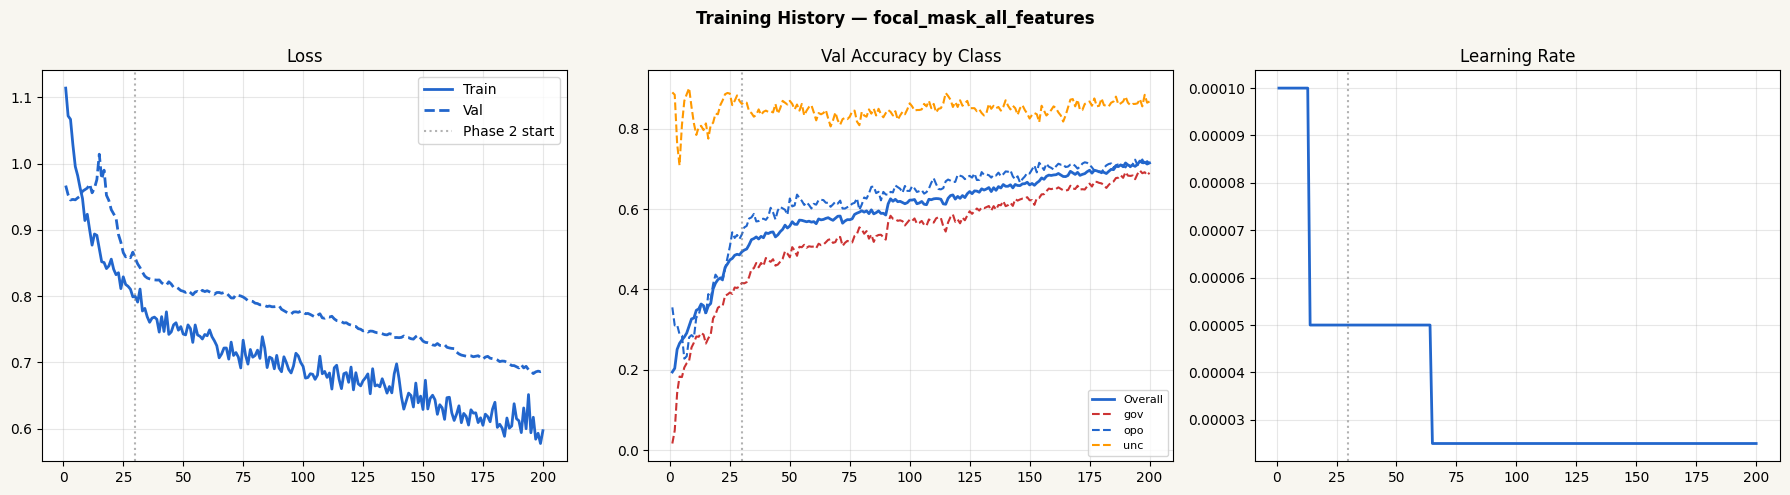

Training curves saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/training_curves.png


In [161]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)
col = '#2266CC'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#F8F6F0')
fig.suptitle('Training History — focal_mask_all_features', fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], color=col, lw=2, label='Train')
ax.plot(epochs_range, history['val_loss'],   color=col, lw=2, ls='--', label='Val')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6, label='Phase 2 start')
ax.set_title('Loss'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, history['val_acc'],          color=col,       lw=2,   label='Overall')
ax.plot(epochs_range, history['val_acc_gov'],       color='#CC3333', lw=1.5, ls='--', label='gov')
ax.plot(epochs_range, history['val_acc_opo'],       color='#2266CC', lw=1.5, ls='--', label='opo')
ax.plot(epochs_range, history['val_acc_uncertain'], color='#FF9900', lw=1.5, ls='--', label='unc')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Val Accuracy by Class'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(epochs_range, history['lr'], color=col, lw=2)
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Learning Rate'); ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = OUT_DIR / 'training_curves.png'
fig.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved: {curves_path}')

In [162]:
# ── Export predictions ────────────────────────────────────────────────────────
all_pred_rows = []
with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = model(X_t)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        preds  = logits.argmax(dim=1)[0].cpu().numpy()

        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr, lc   = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            all_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'confidence'     : float(probs[:, lr, lc].max()),
                'true_class'     : row['target'],
                'has_label'      : True,
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

pred_df = pd.DataFrame(all_pred_rows)
pred_df.to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}  ({len(pred_df):,} rows)')
print(f'Val rows: {(pred_df["is_train_month"] == False).sum():,}')

Predictions saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/predictions.csv  (5,180 rows)
Val rows: 2,562


In [163]:
# ── Permutation importance — baseline F1 ─────────────────────────────────────
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()


def get_val_preds_from_array(X_val_arr):
    """Run inference on a val array; return (all_preds, all_true) flat np arrays."""
    val_ds_tmp = MyanmarRasterDataset(X_val_arr, y_val, m_val, augment=False)
    val_ld_tmp = DataLoader(val_ds_tmp, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    all_preds, all_true = [], []
    with torch.no_grad():
        for Xb, yb, mb in val_ld_tmp:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            logits = model(Xb)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds[mb == 1].cpu().numpy())
            all_true.extend(yb[mb == 1].cpu().numpy())
    return np.array(all_preds), np.array(all_true)


baseline_preds, baseline_true = get_val_preds_from_array(X_val)
baseline_f1 = f1_score(baseline_true, baseline_preds, average='macro', zero_division=0)
print(f'Baseline macro F1: {baseline_f1:.4f}  |  val samples: {len(baseline_true):,}')

Baseline macro F1: 0.6724  |  val samples: 2,562


In [164]:
# ── Permutation importance — channel ablation loop ────────────────────────────
importance_rows = []
for ch_idx, feat_name in enumerate(INPUT_FEATURES):
    X_val_perm = X_val.copy()
    X_val_perm[:, ch_idx, :, :] = 0.0   # zero out in z-scored space (= replace with train mean)
    preds_z, true_z = get_val_preds_from_array(X_val_perm)
    f1_zeroed = f1_score(true_z, preds_z, average='macro', zero_division=0)
    f1_drop   = baseline_f1 - f1_zeroed
    importance_rows.append({
        'feature'    : feat_name,
        'baseline_f1': round(baseline_f1, 6),
        'f1_drop'    : round(f1_drop, 6),
    })
    print(f'[{ch_idx:2d}] {feat_name:40s}  zeroed_f1={f1_zeroed:.4f}  drop={f1_drop:+.4f}')

[ 0] total_events                              zeroed_f1=0.6749  drop=-0.0025
[ 1] is_statebased                             zeroed_f1=0.6624  drop=+0.0100
[ 2] is_onesided                               zeroed_f1=0.6737  drop=-0.0013
[ 3] gov_vs_civilians                          zeroed_f1=0.6708  drop=+0.0016
[ 4] total_fatalities                          zeroed_f1=0.6694  drop=+0.0031
[ 5] deaths_a                                  zeroed_f1=0.6691  drop=+0.0033
[ 6] deaths_b                                  zeroed_f1=0.6689  drop=+0.0035
[ 7] deaths_civilians                          zeroed_f1=0.6689  drop=+0.0035
[ 8] events_gov                                zeroed_f1=0.6667  drop=+0.0057
[ 9] events_nug                                zeroed_f1=0.6768  drop=-0.0044
[10] events_kio                                zeroed_f1=0.6688  drop=+0.0036
[11] events_ula                                zeroed_f1=0.6779  drop=-0.0054
[12] events_knu                                zeroed_f1=0.6778 

In [165]:
# ── Permutation importance — table and plot ───────────────────────────────────
imp_df = pd.DataFrame(importance_rows)
imp_df['relative_importance_%'] = (imp_df['f1_drop'] / baseline_f1 * 100).round(2)
imp_df = imp_df.sort_values('f1_drop', ascending=False).reset_index(drop=True)

print(imp_df.to_string(index=False))
imp_df.to_csv(IMPORTANCE_PATH, index=False)
print(f'\nImportance table saved: {IMPORTANCE_PATH}')

                 feature  baseline_f1   f1_drop  relative_importance_%
       total_events_lag9     0.672413  0.013948                   2.07
     events_pslf_roll12m     0.672413  0.012737                   1.89
      total_events_lag12     0.672413  0.012600                   1.87
        events_gov_std3m     0.672413  0.012256                   1.82
     total_events_roll3m     0.672413  0.012074                   1.80
    total_events_roll12m     0.672413  0.011622                   1.73
      events_pslf_roll3m     0.672413  0.011421                   1.70
         events_nug_lag1     0.672413  0.011077                   1.65
       total_events_lag1     0.672413  0.010847                   1.61
      total_events_std6m     0.672413  0.010819                   1.61
           is_statebased     0.672413  0.009970                   1.48
       events_ula_roll3m     0.672413  0.009820                   1.46
        is_onesided_lag1     0.672413  0.009507                   1.41
      

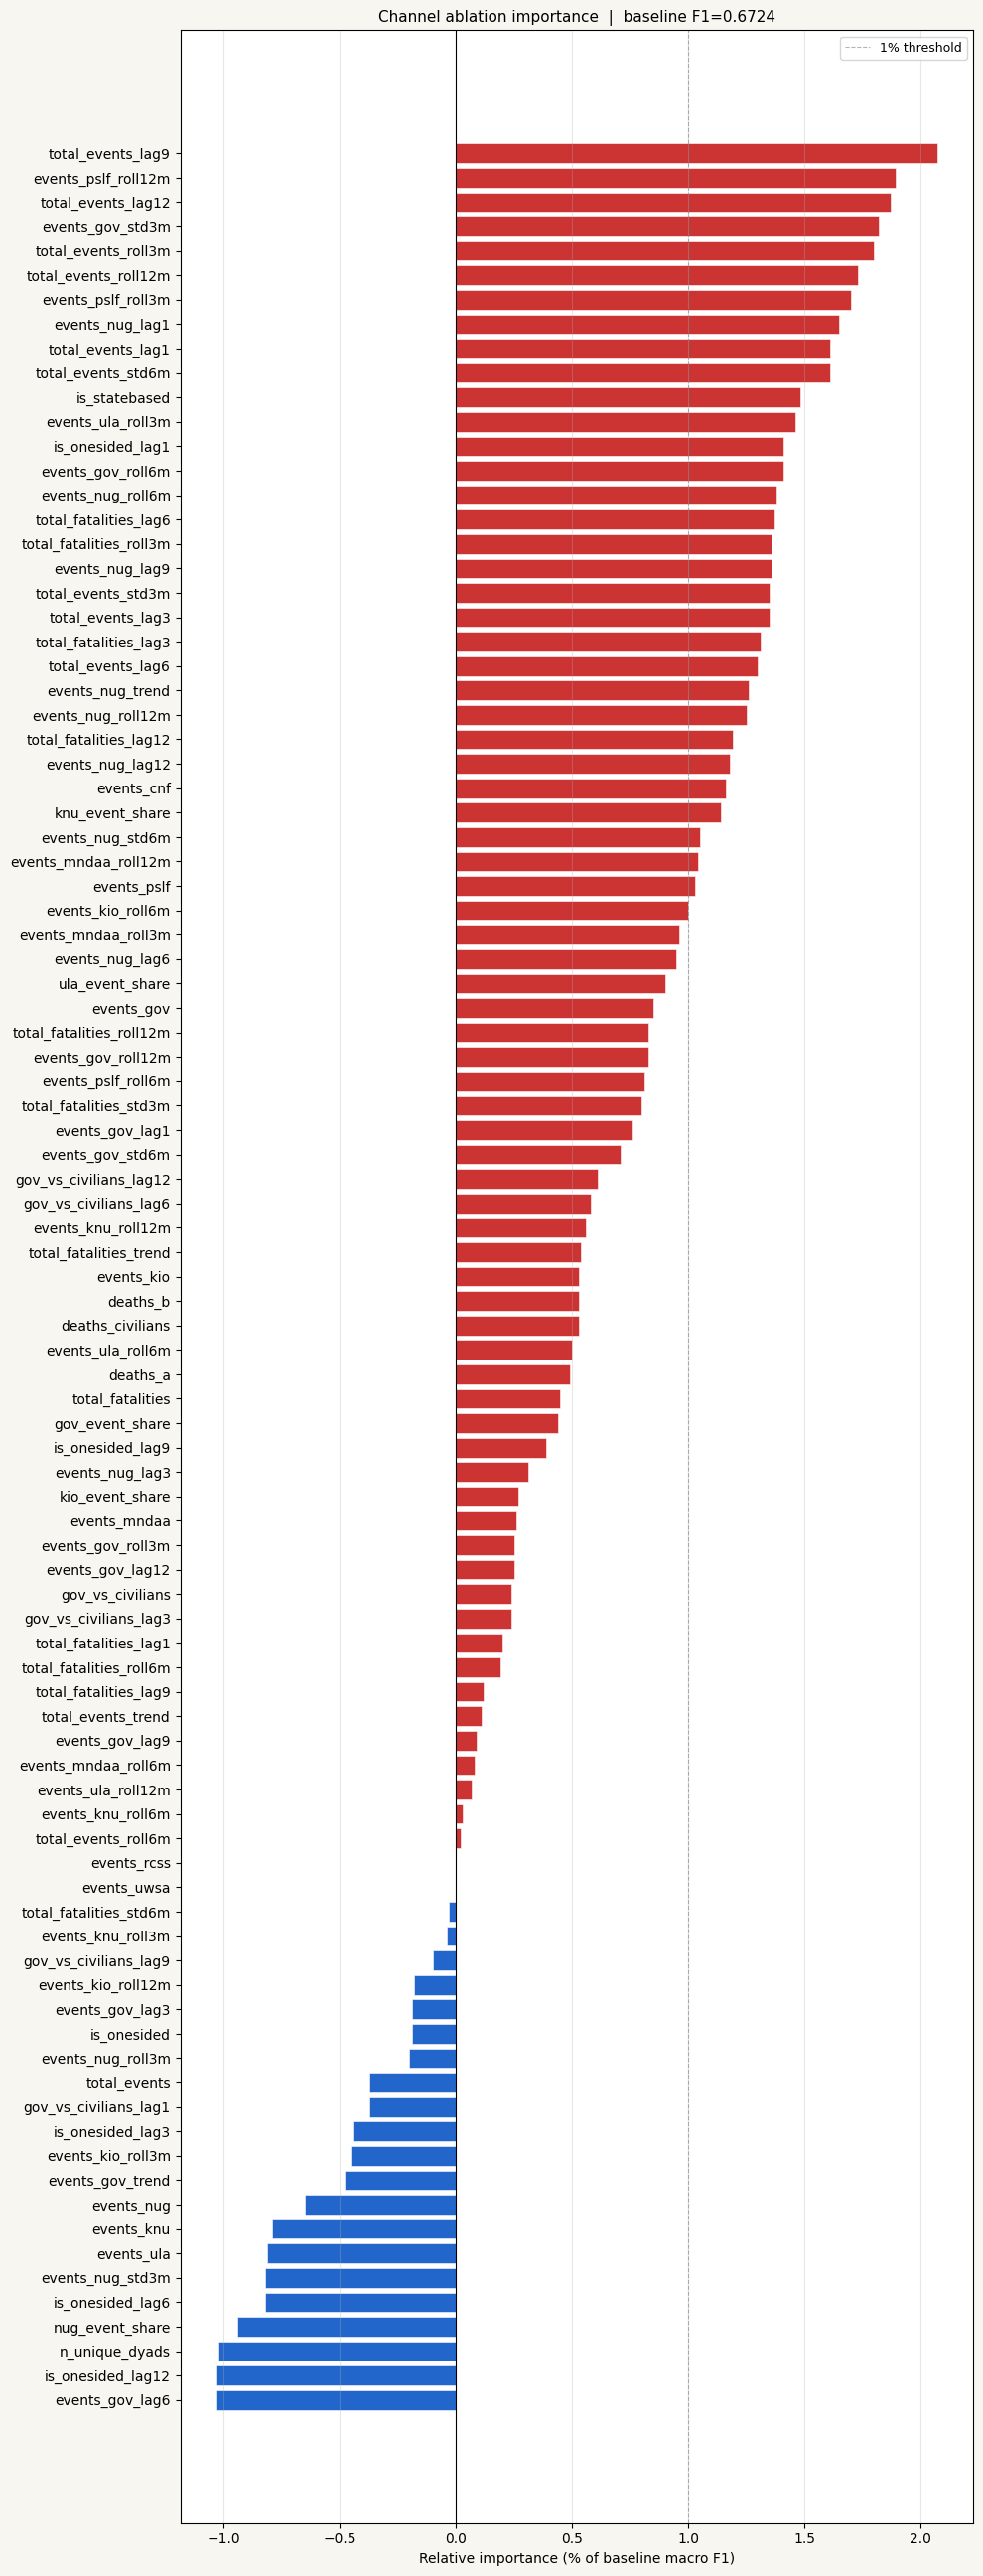

Importance plot saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/feature_importance.png


In [166]:
# ── Permutation importance — horizontal bar chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(imp_df) * 0.28)), facecolor='#F8F6F0')
colors  = ['#CC3333' if v >= 0 else '#2266CC' for v in imp_df['relative_importance_%']]
ax.barh(imp_df['feature'], imp_df['relative_importance_%'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(1, color='grey', linewidth=0.8, ls='--', alpha=0.6, label='1% threshold')
ax.set_xlabel('Relative importance (% of baseline macro F1)')
ax.set_title(f'Channel ablation importance  |  baseline F1={baseline_f1:.4f}', fontsize=11)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plot_path = OUT_DIR / 'feature_importance.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Importance plot saved: {plot_path}')

In [167]:
# ── Candidates to drop (< 1% relative importance) ────────────────────────────
low_imp = imp_df[imp_df['relative_importance_%'] < 1.0]
print(f'Features with < 1% relative importance ({len(low_imp)}/{len(imp_df)}):')
for _, row in low_imp.iterrows():
    print(f"  {row['feature']:40s}  {row['relative_importance_%']:+.2f}%")

print('\nCOMPLETE.')

Features with < 1% relative importance (61/93):
  events_mndaa_roll3m                       +0.96%
  events_nug_lag6                           +0.95%
  ula_event_share                           +0.90%
  events_gov                                +0.85%
  total_fatalities_roll12m                  +0.83%
  events_gov_roll12m                        +0.83%
  events_pslf_roll6m                        +0.81%
  total_fatalities_std3m                    +0.80%
  events_gov_lag1                           +0.76%
  events_gov_std6m                          +0.71%
  gov_vs_civilians_lag12                    +0.61%
  gov_vs_civilians_lag6                     +0.58%
  events_knu_roll12m                        +0.56%
  total_fatalities_trend                    +0.54%
  events_kio                                +0.53%
  deaths_b                                  +0.53%
  deaths_civilians                          +0.53%
  events_ula_roll6m                         +0.50%
  deaths_a                        

In [168]:

# ── Eval helper (mirrors focal_mask_eval.py) ──────────────────────────────────
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

LABEL_MAP_R = {'gov': 0, 'opo': 1, 'uncertain': 2}


def run_eval(pred_df):
    val_df = pred_df[pred_df['is_train_month'] == False].copy()
    val_df['true_int'] = val_df['true_class'].map(LABEL_MAP_R)
    val_df['pred_int'] = val_df['pred_class'].map(LABEL_MAP_R)
    y_true = val_df['true_int'].values
    y_pred = val_df['pred_int'].values
    n_val  = len(val_df)

    report      = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                        output_dict=True, zero_division=0)
    overall_acc = (y_true == y_pred).mean()
    cm          = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_norm     = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    val_sorted               = val_df.sort_values(['priogrid_gid', 'year_month']).copy()
    val_sorted['prev_true']  = val_sorted.groupby('priogrid_gid')['true_int'].shift(1)
    transitions              = val_sorted.dropna(subset=['prev_true']).copy()
    transitions['prev_true'] = transitions['prev_true'].astype(int)
    transitions['is_trans']  = transitions['true_int'] != transitions['prev_true']
    trans_only = transitions[transitions['is_trans']].copy()
    stable     = transitions[~transitions['is_trans']].copy()

    trans_correct  = (trans_only['true_int'] == trans_only['pred_int']).sum()
    stable_correct = (stable['true_int']     == stable['pred_int']).sum()

    trans_only['from_cls'] = trans_only['prev_true'].map(INV_LABEL)
    trans_only['to_cls']   = trans_only['true_int'].map(INV_LABEL)
    trans_only['hit']      = trans_only['true_int'] == trans_only['pred_int']

    return {
        'report'        : report,
        'cm'            : cm,
        'cm_norm'       : cm_norm,
        'acc'           : overall_acc,
        'n_val'         : n_val,
        'trans_acc'     : trans_correct / max(len(trans_only), 1),
        'stable_acc'    : stable_correct / max(len(stable), 1),
        'n_trans'       : len(trans_only),
        'n_stable'      : len(stable),
        'trans_only_df' : trans_only,
    }


In [169]:

# ── Train model with only ≥1% importance features ────────────────────────────
IMP_FEATURES = imp_df[imp_df['relative_importance_%'] >= 1.0]['feature'].tolist()
N_IMP        = len(IMP_FEATURES)
IMP_OUT_DIR  = MODELS_DIR / 'focal_mask_important_features'
IMP_OUT_DIR.mkdir(parents=True, exist_ok=True)
IMP_WEIGHTS_PATH     = IMP_OUT_DIR / 'weights.pt'
IMP_PREDICTIONS_PATH = IMP_OUT_DIR / 'predictions.csv'
print(f'Important features ({N_IMP}): {IMP_FEATURES}')

imp_X_rasters = []
for month in months_with_labels:
    md_ = labelled[labelled['year_month'] == month]
    X_r = np.zeros((PAD_H, PAD_W, N_IMP), dtype=np.float32)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local:
            continue
        lr, lc         = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[IMP_FEATURES].values
    imp_X_rasters.append(np.transpose(X_r, (2, 0, 1)))

imp_X_array = np.stack(imp_X_rasters)
imp_X_train = imp_X_array[train_idx]
imp_X_val   = imp_X_array[val_idx]
print(f'Raster shape: {imp_X_array.shape}')

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
imp_model = smp.Unet(
    encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
    in_channels=N_IMP, classes=NUM_CLASSES,
    activation=None, decoder_channels=(128, 64, 32, 16), encoder_depth=4,
).to(DEVICE)

imp_opt, imp_sched = build_optimizer(imp_model)

g = torch.Generator(); g.manual_seed(SEED)
imp_tr_ds = MyanmarRasterDataset(imp_X_train, y_train, m_train, augment=True)
imp_va_ds = MyanmarRasterDataset(imp_X_val,   y_val,   m_val,   augment=False)
imp_tr_ld = DataLoader(imp_tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0,
                       drop_last=False, generator=g, worker_init_fn=seed_worker)
imp_va_ld = DataLoader(imp_va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imp_history      = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc',
                                     'val_acc_gov', 'val_acc_opo', 'val_acc_uncertain', 'lr']}
imp_best_val_loss, imp_best_wts = float('inf'), None
freeze_encoder(imp_model)

print(f'\nTraining: {NUM_EPOCHS} epochs, {N_IMP} channels')
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_encoder(imp_model, imp_opt, UNFREEZE_LR)

    imp_model.train()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    for Xb, yb, mb in imp_tr_ld:
        Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        imp_opt.zero_grad()
        preds = imp_model(Xb)
        loss  = focal_combined_loss(preds, yb, mb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(imp_model.parameters(), max_norm=1.0)
        imp_opt.step()
        m_ = compute_metrics(preds.detach(), yb, mb)
        e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
    avg_tl, avg_ta = e_loss / nb, e_acc / nb

    imp_model.eval()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    imp_cls_ = {'gov': [], 'opo': [], 'uncertain': []}
    with torch.no_grad():
        for Xb, yb, mb in imp_va_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            preds = imp_model(Xb)
            loss  = combined_loss(preds, yb, mb)
            m_    = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
            for c in CLASS_NAMES:
                if not np.isnan(m_.get(c, float('nan'))):
                    imp_cls_[c].append(m_[c])
    avg_vl, avg_va = e_loss / nb, e_acc / nb
    avg_cls = {c: np.mean(v) if v else float('nan') for c, v in imp_cls_.items()}

    imp_sched.step(avg_vl)
    imp_history['train_loss'].append(avg_tl); imp_history['val_loss'].append(avg_vl)
    imp_history['train_acc'].append(avg_ta);  imp_history['val_acc'].append(avg_va)
    imp_history['val_acc_gov'].append(avg_cls['gov'])
    imp_history['val_acc_opo'].append(avg_cls['opo'])
    imp_history['val_acc_uncertain'].append(avg_cls['uncertain'])
    imp_history['lr'].append(imp_opt.param_groups[0]['lr'])

    if avg_vl < imp_best_val_loss:
        imp_best_val_loss = avg_vl
        imp_best_wts      = copy.deepcopy(imp_model.state_dict())
        torch.save(imp_best_wts, IMP_WEIGHTS_PATH)
        ck = ' <- best'
    else:
        ck = ''

    if epoch % 10 == 0 or epoch == 1:
        ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
        print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
              f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}{ck}')

imp_model.load_state_dict(torch.load(IMP_WEIGHTS_PATH, map_location=DEVICE))
imp_model.eval()
print(f'\nBest val loss: {imp_best_val_loss:.4f}  |  weights: {IMP_WEIGHTS_PATH}')

# Export predictions (with probabilities)
imp_pred_rows = []
with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(imp_X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = imp_model(X_t)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        preds  = logits.argmax(dim=1)[0].cpu().numpy()
        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr, lc   = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            imp_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'true_class'     : row['target'],
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

imp_pred_df = pd.DataFrame(imp_pred_rows)
imp_pred_df.to_csv(IMP_PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {IMP_PREDICTIONS_PATH}  ({len(imp_pred_df):,} rows)')


Important features (32): ['total_events_lag9', 'events_pslf_roll12m', 'total_events_lag12', 'events_gov_std3m', 'total_events_roll3m', 'total_events_roll12m', 'events_pslf_roll3m', 'events_nug_lag1', 'total_events_lag1', 'total_events_std6m', 'is_statebased', 'events_ula_roll3m', 'is_onesided_lag1', 'events_gov_roll6m', 'events_nug_roll6m', 'total_fatalities_lag6', 'total_fatalities_roll3m', 'events_nug_lag9', 'total_events_std3m', 'total_events_lag3', 'total_fatalities_lag3', 'total_events_lag6', 'events_nug_trend', 'events_nug_roll12m', 'total_fatalities_lag12', 'events_nug_lag12', 'events_cnf', 'knu_event_share', 'events_nug_std6m', 'events_mndaa_roll12m', 'events_pslf', 'events_kio_roll6m']
Raster shape: (29, 32, 40, 16)

Training: 200 epochs, 32 channels
  Ep   1/200 [P1]  tr 1.109/0.252  val 0.974/0.182 <- best
  Ep  10/200 [P1]  tr 0.926/0.359  val 0.933/0.352 <- best
  Ep  20/200 [P1]  tr 0.819/0.493  val 0.876/0.467 <- best
  Ep  30/200 [P1]  tr 0.749/0.561  val 0.842/0.537 <-

In [170]:

# ── Random baseline — proportional sampling from training class distribution ───
np.random.seed(SEED)
train_labels = labelled[labelled['year_month'] <= TRAIN_CUTOFF]['target']
class_props  = train_labels.value_counts(normalize=True).reindex(['gov', 'opo', 'uncertain']).fillna(0)
p_gov, p_opo, p_unc = class_props['gov'], class_props['opo'], class_props['uncertain']
print(f'Training class proportions  gov={p_gov:.1%}  opo={p_opo:.1%}  uncertain={p_unc:.1%}')

# Use pred_df as the row template (same cells × months as all other models)
rand_base = pred_df[['priogrid_gid', 'year_month', 'true_class', 'is_train_month']].copy()
rand_preds = np.random.choice(['gov', 'opo', 'uncertain'], size=len(rand_base),
                               p=[p_gov, p_opo, p_unc])
rand_base['pred_class']     = rand_preds
rand_base['pred_class_int'] = rand_base['pred_class'].map(LABEL_MAP_R)
# Constant probability scores = class proportions (calibrated random)
rand_base['prob_gov']       = p_gov
rand_base['prob_opo']       = p_opo
rand_base['prob_uncertain'] = p_unc
random_pred_df = rand_base

# ── Load original 10-feature predictions + build VARIANTS ─────────────────────
ORIG_PRED_PATH = MODELS_DIR / 'focal_mask' / 'predictions.csv'

VARIANTS = {
    'all_features (93ch)'        : pred_df,
    f'important ≥1% ({N_IMP}ch)': imp_pred_df,
    'random baseline'            : random_pred_df,
}
if ORIG_PRED_PATH.exists():
    orig_df = pd.read_csv(ORIG_PRED_PATH)
    # Insert original 10ch before random baseline
    VARIANTS = {
        'all_features (93ch)'        : pred_df,
        f'important ≥1% ({N_IMP}ch)': imp_pred_df,
        'original 10ch'              : orig_df,
        'random baseline'            : random_pred_df,
    }
else:
    print(f'WARNING: {ORIG_PRED_PATH} not found — run focal_mask_export_predictions.py first.')

results = {name: run_eval(df) for name, df in VARIANTS.items()}

# ── Comparison table ──────────────────────────────────────────────────────────
hdr = (f'{"Model":<26} {"N val":>6} {"Acc":>7} {"Macro F1":>9}'
       f' {"Gov F1":>8} {"Opo F1":>8} {"Unc F1":>8} {"Trans%":>8} {"Stable%":>8}')
print(hdr)
print('-' * len(hdr))
for name, r in results.items():
    rep = r['report']
    print(
        f'{name:<26} {r["n_val"]:>6,} {r["acc"]:>6.1%} '
        f'{rep["macro avg"]["f1-score"]:>8.1%} '
        f'{rep["gov"]["f1-score"]:>7.1%} '
        f'{rep["opo"]["f1-score"]:>7.1%} '
        f'{rep["uncertain"]["f1-score"]:>7.1%} '
        f'{r["trans_acc"]:>7.1%} '
        f'{r["stable_acc"]:>7.1%}'
    )

print()
print('Misclassification breakdown:')
for name, r in results.items():
    cm, cm_norm = r['cm'], r['cm_norm']
    print(f'\n  [{name}]')
    for i, tc in enumerate(CLASS_NAMES):
        for j, pc in enumerate(CLASS_NAMES):
            n = cm[i, j]
            if i != j and n > 0:
                print(f'    True {tc:>9} → pred {pc:>9}: {n:4d}  ({100*cm_norm[i,j]:.1f}%)')


Training class proportions  gov=62.0%  opo=17.2%  uncertain=20.8%
Model                       N val     Acc  Macro F1   Gov F1   Opo F1   Unc F1   Trans%  Stable%
------------------------------------------------------------------------------------------------
all_features (93ch)         2,562  71.9%    67.2%   78.3%   71.0%   52.4%   28.3%   73.2%
important ≥1% (32ch)        2,562  87.5%    83.6%   91.5%   80.6%   78.6%   36.7%   88.1%
original 10ch               2,562  86.0%    81.8%   90.6%   79.0%   75.7%   38.3%   86.8%
random baseline             2,562  45.9%    31.6%   63.6%   18.1%   13.2%   33.3%   45.9%

Misclassification breakdown:

  [all_features (93ch)]
    True       gov → pred       opo:  171  (10.4%)
    True       gov → pred uncertain:  333  (20.2%)
    True       opo → pred       gov:  115  (17.9%)
    True       opo → pred uncertain:   66  (10.3%)
    True uncertain → pred       gov:   13  (4.7%)
    True uncertain → pred       opo:   23  (8.4%)

  [important ≥1% (32

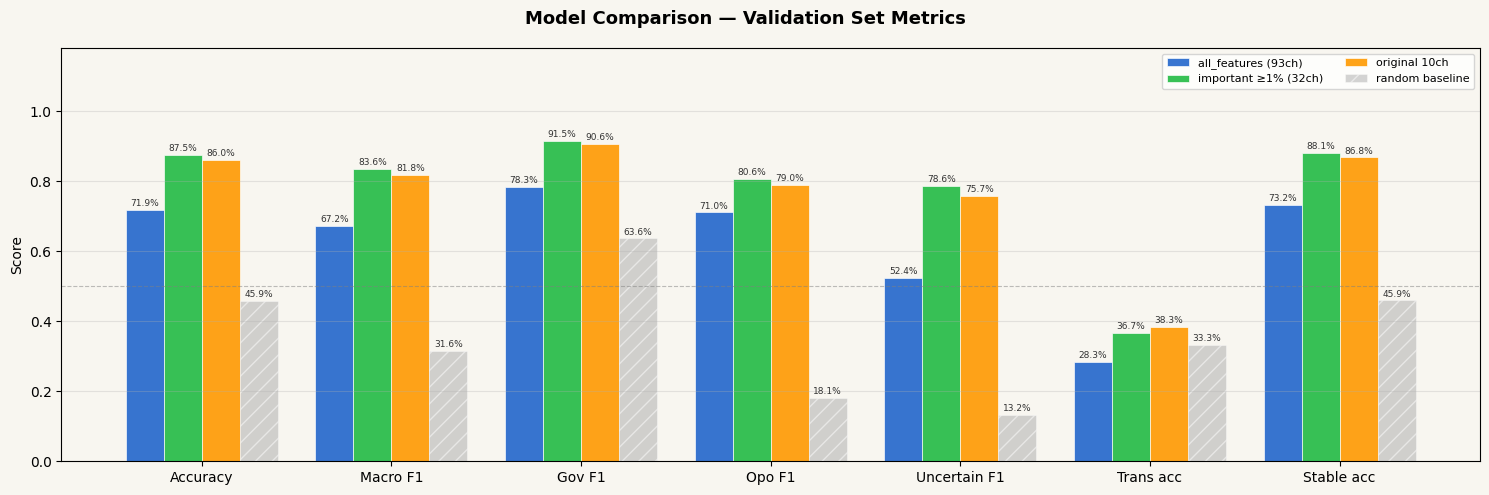

Metrics comparison chart saved.


In [171]:

# ── Summary metrics bar chart — all models + random baseline ──────────────────
metrics_to_plot = {
    'Accuracy'    : [r['acc']                               for r in results.values()],
    'Macro F1'    : [r['report']['macro avg']['f1-score']   for r in results.values()],
    'Gov F1'      : [r['report']['gov']['f1-score']         for r in results.values()],
    'Opo F1'      : [r['report']['opo']['f1-score']         for r in results.values()],
    'Uncertain F1': [r['report']['uncertain']['f1-score']   for r in results.values()],
    'Trans acc'   : [r['trans_acc']                         for r in results.values()],
    'Stable acc'  : [r['stable_acc']                        for r in results.values()],
}
model_names = list(results.keys())
n_metrics   = len(metrics_to_plot)
n_models    = len(model_names)
palette     = ['#2266CC', '#22BB44', '#FF9900', '#AAAAAA'][:n_models]   # grey for random

x       = np.arange(n_metrics)
width   = 0.8 / n_models
offsets = [(i - (n_models - 1) / 2) * width for i in range(n_models)]

fig, ax = plt.subplots(figsize=(15, 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
fig.suptitle('Model Comparison — Validation Set Metrics', fontsize=13, fontweight='bold')

for i, (name, color, offset) in enumerate(zip(model_names, palette, offsets)):
    vals  = [metrics_to_plot[m][i] for m in metrics_to_plot]
    alpha = 0.5 if 'random' in name else 0.9
    bars  = ax.bar(x + offset, vals, width, label=name, color=color,
                   edgecolor='white', linewidth=0.5, alpha=alpha,
                   hatch='//' if 'random' in name else '')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=6.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics comparison chart saved.')


AUC-ROC  (macro / gov / opo / uncertain)  — Overall
  all_features (93ch)         macro=0.899  gov=0.872  opo=0.899  unc=0.926
  important ≥1% (32ch)        macro=0.960  gov=0.944  opo=0.953  unc=0.982
  original 10ch               macro=0.952  gov=0.935  opo=0.943  unc=0.978
  random baseline             macro=0.500  gov=0.500  opo=0.500  unc=0.500

AUC-ROC  — Transitions only
  all_features (93ch)         macro=0.538  gov=0.464  opo=0.514  unc=0.598  (n=60)
  important ≥1% (32ch)        macro=0.623  gov=0.451  opo=0.590  unc=0.784  (n=60)
  original 10ch               macro=0.621  gov=0.435  opo=0.522  unc=0.868  (n=60)
  random baseline             macro=0.500  gov=0.500  opo=0.500  unc=0.500  (n=60)

Avg Precision  — Overall
  all_features (93ch)         macro=0.793  gov=0.917  opo=0.776  unc=0.686
  important ≥1% (32ch)        macro=0.916  gov=0.960  opo=0.908  unc=0.879
  original 10ch               macro=0.899  gov=0.958  opo=0.886  unc=0.853
  random baseline             macro=

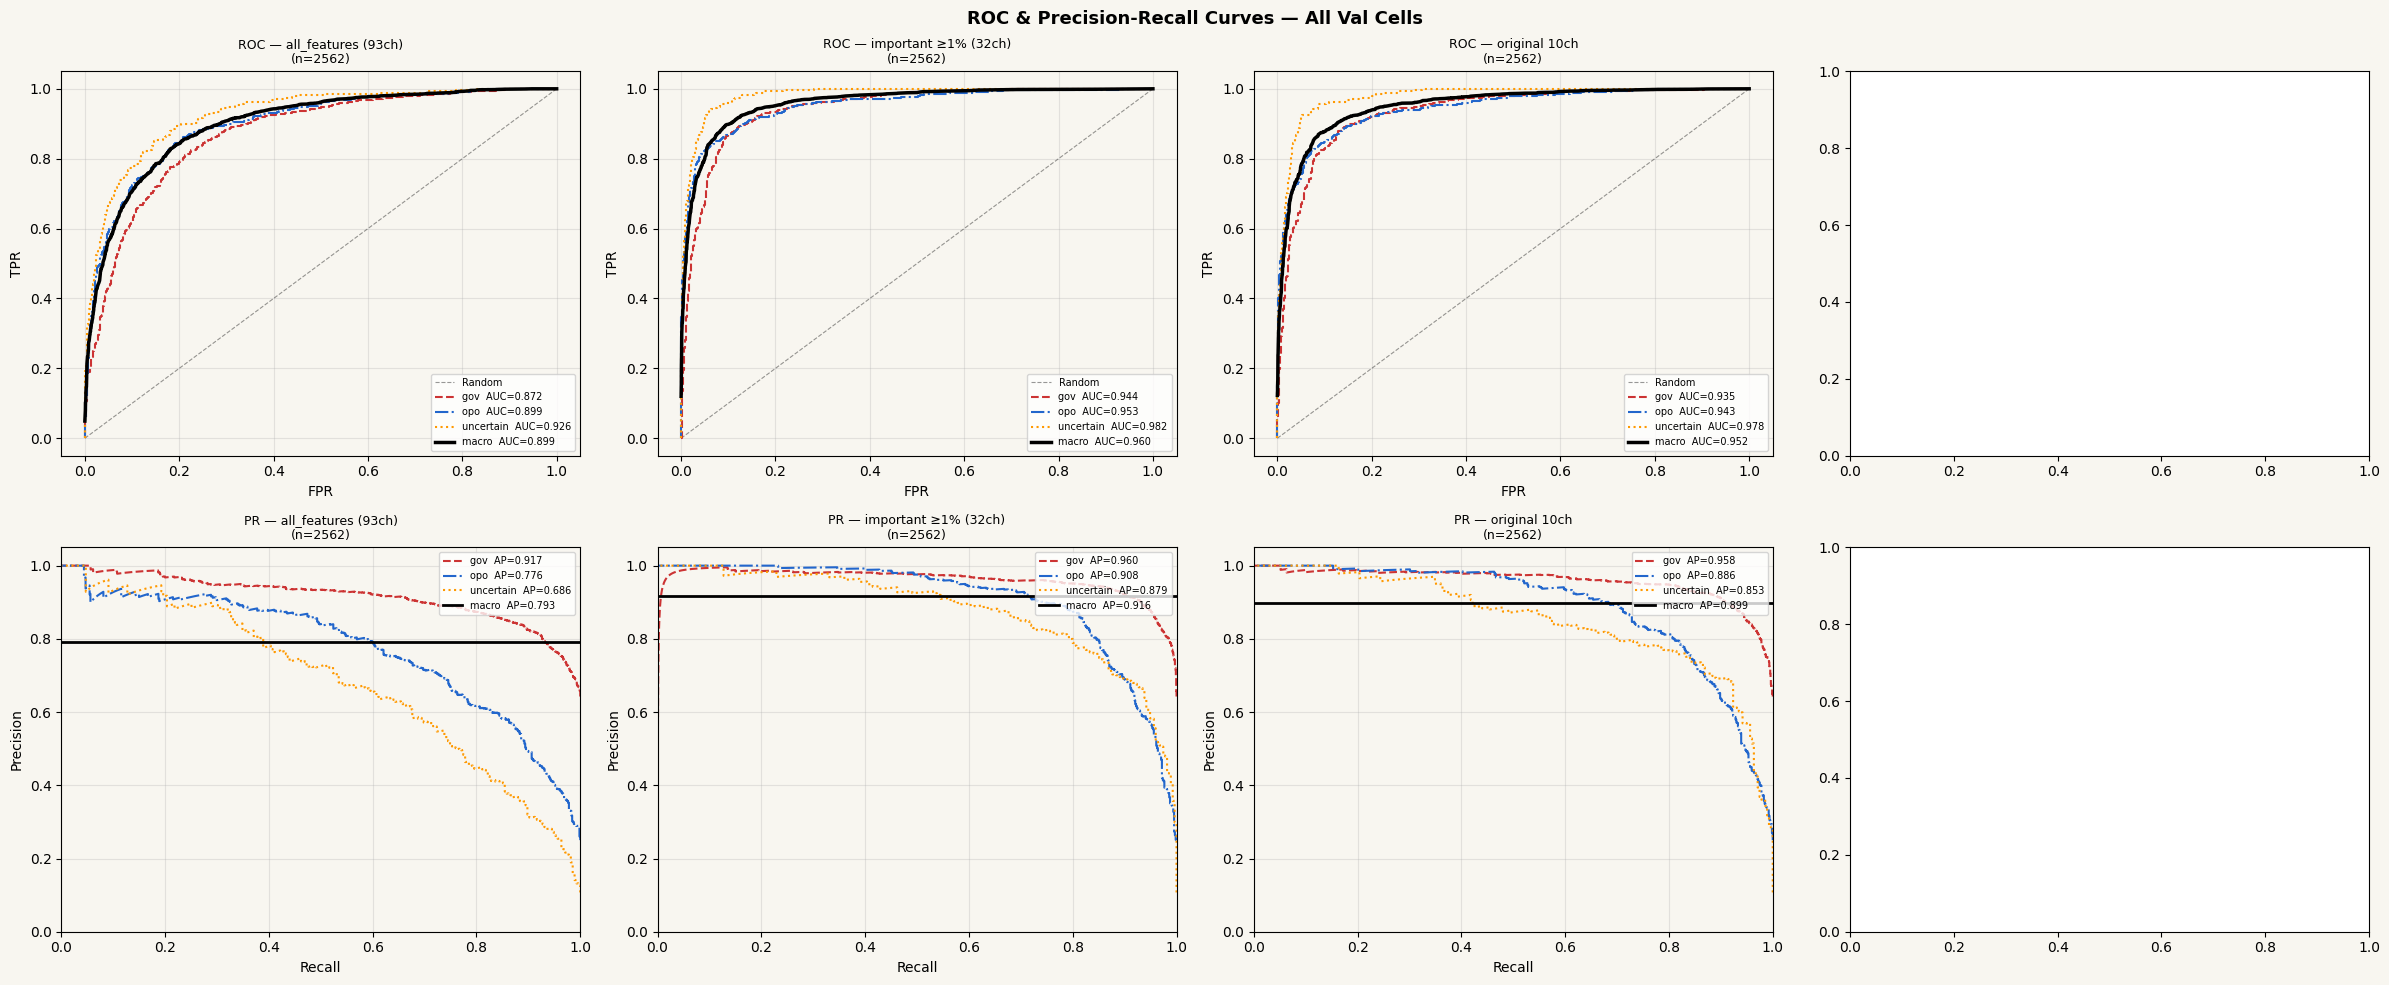

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/eval_roc_pr_overall.png


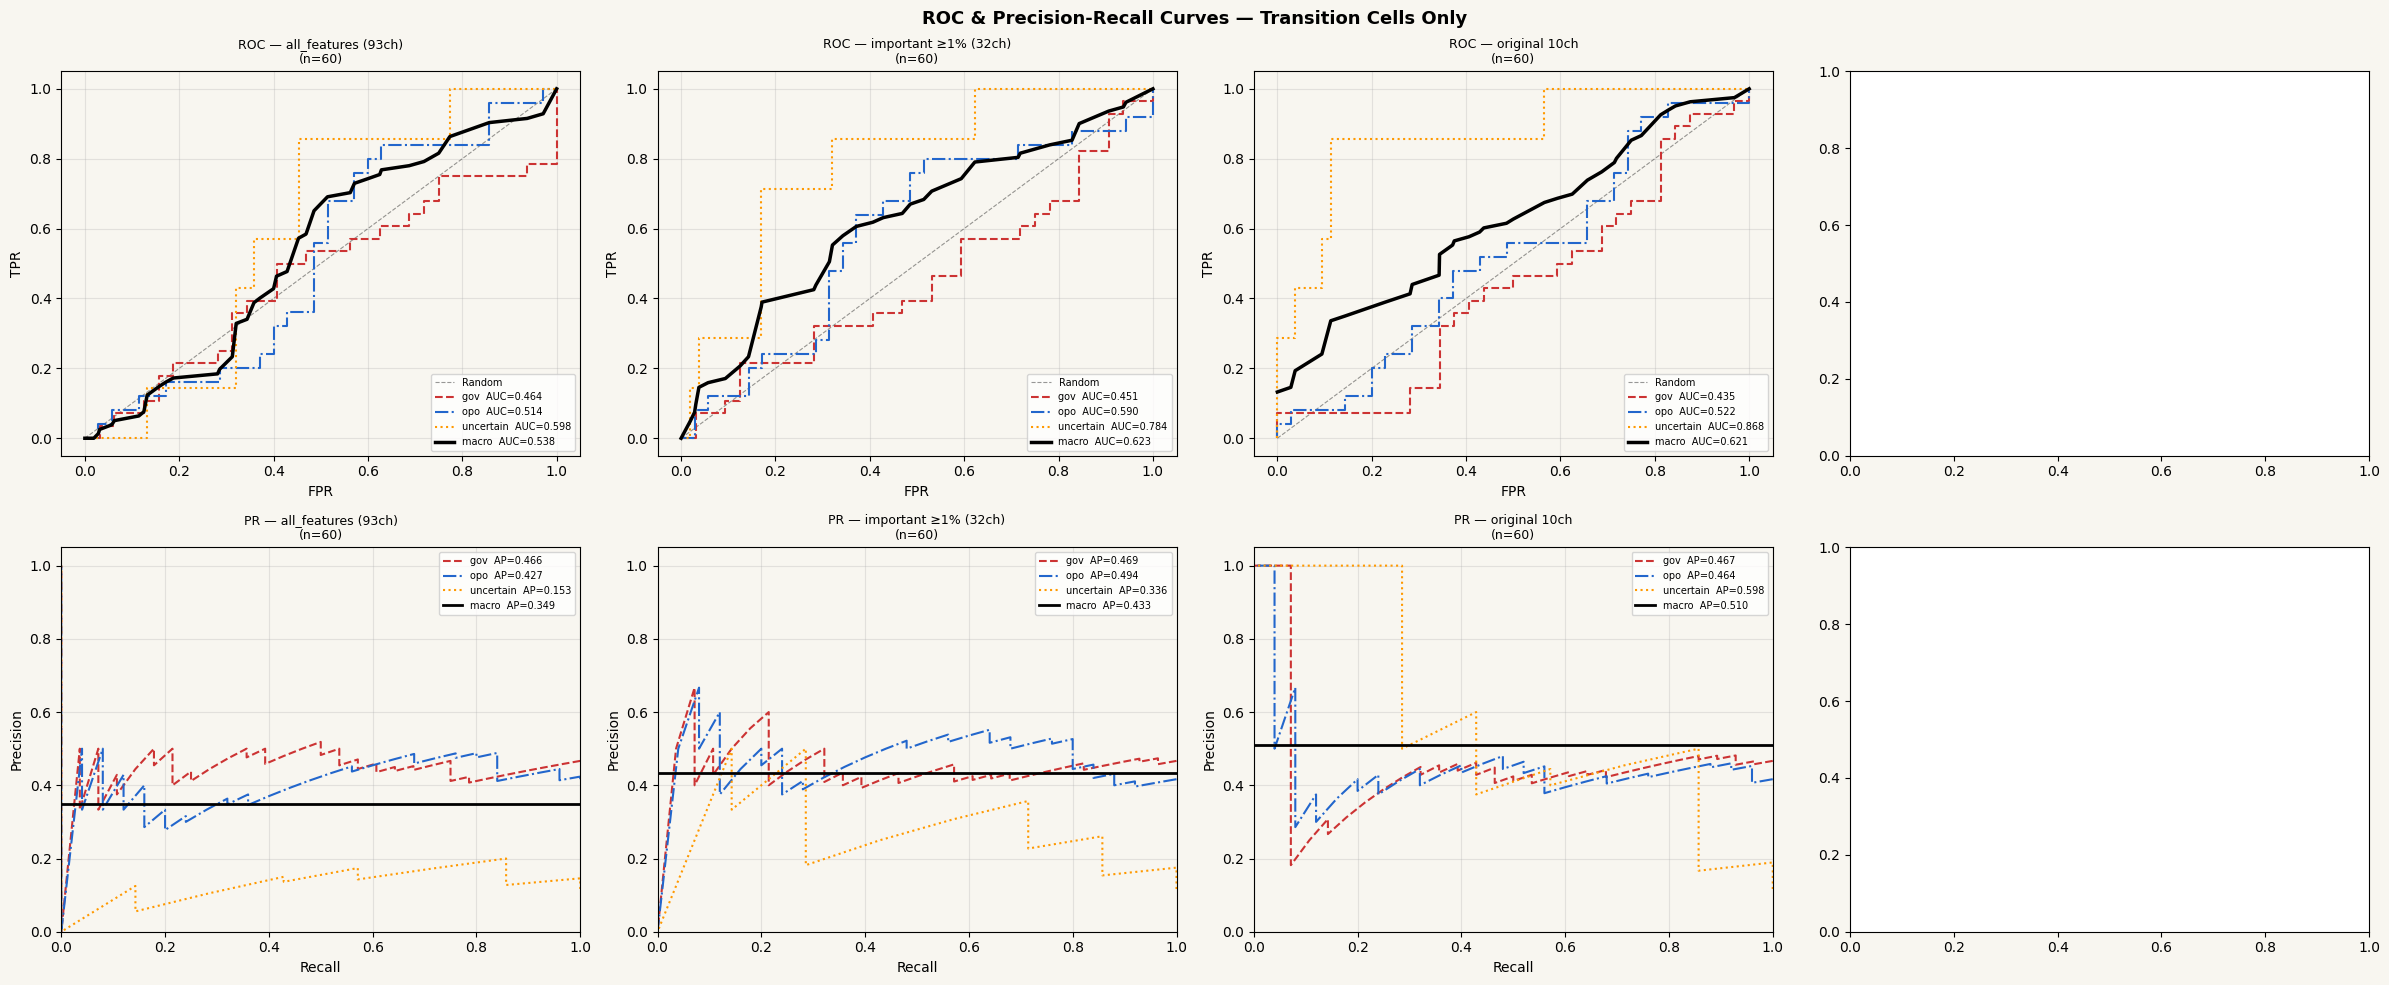

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/eval_roc_pr_transitions.png


In [172]:

# ── ROC & Precision-Recall curves — overall + transition cells ────────────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

PROB_COLS  = ['prob_gov', 'prob_opo', 'prob_uncertain']
CLS_COLORS = {'gov': '#CC3333', 'opo': '#2266CC', 'uncertain': '#FF9900', 'macro': 'black'}
CLS_LS     = {'gov': '--', 'opo': '-.', 'uncertain': ':', 'macro': '-'}


def compute_curves(df, trans_keys=None):
    """
    Returns dict with roc and pr data per class + macro.
    trans_keys: set of (priogrid_gid, year_month) tuples for transition cells.
    """
    val = df[df['is_train_month'] == False].copy()
    val['true_int'] = val['true_class'].map(LABEL_MAP_R)

    if trans_keys is not None:
        mask = val.apply(lambda r: (r['priogrid_gid'], r['year_month']) in trans_keys, axis=1)
        val  = val[mask]

    if len(val) == 0 or not all(c in val.columns for c in PROB_COLS):
        return None

    y_true = val['true_int'].values
    y_prob = val[PROB_COLS].values
    y_bin  = label_binarize(y_true, classes=[0, 1, 2])

    roc, pr = {}, {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc[cls]    = {'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)}
        prec, rec, _= precision_recall_curve(y_bin[:, i], y_prob[:, i])
        pr[cls]     = {'prec': prec, 'rec': rec,
                       'ap': average_precision_score(y_bin[:, i], y_prob[:, i])}

    # macro ROC (interpolate on common fpr grid)
    all_fpr  = np.unique(np.concatenate([roc[c]['fpr'] for c in CLASS_NAMES]))
    mean_tpr = sum(np.interp(all_fpr, roc[c]['fpr'], roc[c]['tpr']) for c in CLASS_NAMES) / 3
    roc['macro'] = {'fpr': all_fpr, 'tpr': mean_tpr, 'auc': auc(all_fpr, mean_tpr)}
    pr['macro']  = {'ap': np.mean([pr[c]['ap'] for c in CLASS_NAMES])}

    return {'roc': roc, 'pr': pr, 'n': len(val)}


# Build transition key sets per variant
trans_keys_per = {
    name: set(zip(r['trans_only_df']['priogrid_gid'], r['trans_only_df']['year_month']))
    for name, r in results.items()
}

curves_overall = {name: compute_curves(df)
                  for name, df in VARIANTS.items()}
curves_trans   = {name: compute_curves(df, trans_keys_per.get(name))
                  for name, df in VARIANTS.items()}

# ── Print AUC / AP summary table ──────────────────────────────────────────────
print('AUC-ROC  (macro / gov / opo / uncertain)  — Overall')
for name, c in curves_overall.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["roc"]["macro"]["auc"]:.3f} '
          f' gov={c["roc"]["gov"]["auc"]:.3f}'
          f'  opo={c["roc"]["opo"]["auc"]:.3f}'
          f'  unc={c["roc"]["uncertain"]["auc"]:.3f}')

print('\nAUC-ROC  — Transitions only')
for name, c in curves_trans.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["roc"]["macro"]["auc"]:.3f} '
          f' gov={c["roc"]["gov"]["auc"]:.3f}'
          f'  opo={c["roc"]["opo"]["auc"]:.3f}'
          f'  unc={c["roc"]["uncertain"]["auc"]:.3f}  (n={c["n"]})')

print('\nAvg Precision  — Overall')
for name, c in curves_overall.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["pr"]["macro"]["ap"]:.3f} '
          f' gov={c["pr"]["gov"]["ap"]:.3f}'
          f'  opo={c["pr"]["opo"]["ap"]:.3f}'
          f'  unc={c["pr"]["uncertain"]["ap"]:.3f}')

print('\nAvg Precision  — Transitions only')
for name, c in curves_trans.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["pr"]["macro"]["ap"]:.3f} '
          f' gov={c["pr"]["gov"]["ap"]:.3f}'
          f'  opo={c["pr"]["opo"]["ap"]:.3f}'
          f'  unc={c["pr"]["uncertain"]["ap"]:.3f}  (n={c["n"]})')


def plot_roc_pr(curves_dict, title_suffix, out_suffix):
    names      = [n for n, c in curves_dict.items() if c is not None]
    n_variants = len(names)
    palette_m  = ['#2266CC', '#22BB44', '#FF9900'][:n_variants]

    fig, axes = plt.subplots(2, n_variants, figsize=(6 * n_variants, 10),
                             facecolor='#F8F6F0')
    if n_variants == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(f'ROC & Precision-Recall Curves — {title_suffix}',
                 fontsize=13, fontweight='bold')

    for col, (name, col_color) in enumerate(zip(names, palette_m)):
        c = curves_dict[name]

        # ROC
        ax = axes[0, col]
        ax.set_facecolor('#F8F6F0')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random')
        for cls in CLASS_NAMES + ['macro']:
            rd = c['roc'][cls]
            lw = 2.5 if cls == 'macro' else 1.5
            ax.plot(rd['fpr'], rd['tpr'], color=CLS_COLORS[cls], ls=CLS_LS[cls],
                    lw=lw, label=f'{cls}  AUC={rd["auc"]:.3f}')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC — {name}\n(n={c["n"]})', fontsize=9)
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

        # PR
        ax = axes[1, col]
        ax.set_facecolor('#F8F6F0')
        for cls in CLASS_NAMES:
            pd_ = c['pr'][cls]
            ax.plot(pd_['rec'], pd_['prec'], color=CLS_COLORS[cls], ls=CLS_LS[cls],
                    lw=1.5, label=f'{cls}  AP={pd_["ap"]:.3f}')
        macro_ap = c['pr']['macro']['ap']
        ax.axhline(macro_ap, color='black', lw=2, ls='-',
                   label=f'macro  AP={macro_ap:.3f}')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f'PR — {name}\n(n={c["n"]})', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

    plt.tight_layout()
    save_path = OUT_DIR / f'eval_roc_pr_{out_suffix}.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_roc_pr(curves_overall, 'All Val Cells',       'overall')
plot_roc_pr(curves_trans,   'Transition Cells Only', 'transitions')


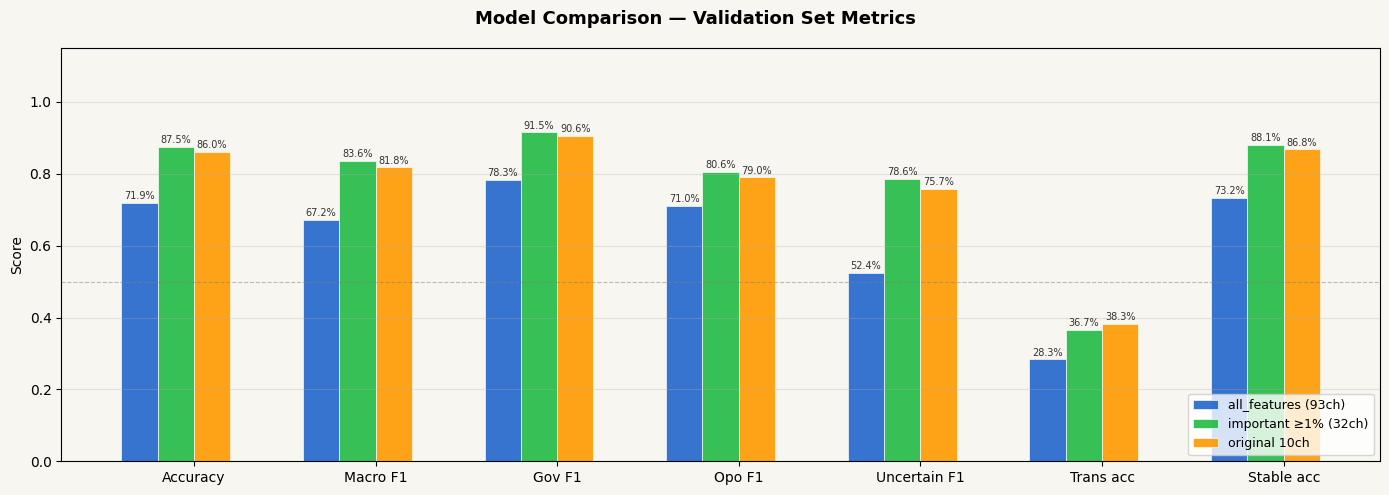

Metrics comparison chart saved.


In [173]:

# ── Summary metrics bar chart — 3-model comparison ───────────────────────────
metrics_to_plot = {
    'Accuracy'   : [r['acc']                               for r in results.values()],
    'Macro F1'   : [r['report']['macro avg']['f1-score']   for r in results.values()],
    'Gov F1'     : [r['report']['gov']['f1-score']         for r in results.values()],
    'Opo F1'     : [r['report']['opo']['f1-score']         for r in results.values()],
    'Uncertain F1': [r['report']['uncertain']['f1-score']  for r in results.values()],
    'Trans acc'  : [r['trans_acc']                         for r in results.values()],
    'Stable acc' : [r['stable_acc']                        for r in results.values()],
}
model_names = list(results.keys())
n_metrics   = len(metrics_to_plot)
n_models    = len(model_names)
palette     = ['#2266CC', '#22BB44', '#FF9900'][:n_models]

x      = np.arange(n_metrics)
width  = 0.8 / n_models
offsets = [(i - (n_models - 1) / 2) * width for i in range(n_models)]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
fig.suptitle('Model Comparison — Validation Set Metrics', fontsize=13, fontweight='bold')

for i, (name, color, offset) in enumerate(zip(model_names, palette, offsets)):
    vals = [metrics_to_plot[m][i] for m in metrics_to_plot]
    bars = ax.bar(x + offset, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=7, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.legend(fontsize=9, loc='lower right')
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics comparison chart saved.')


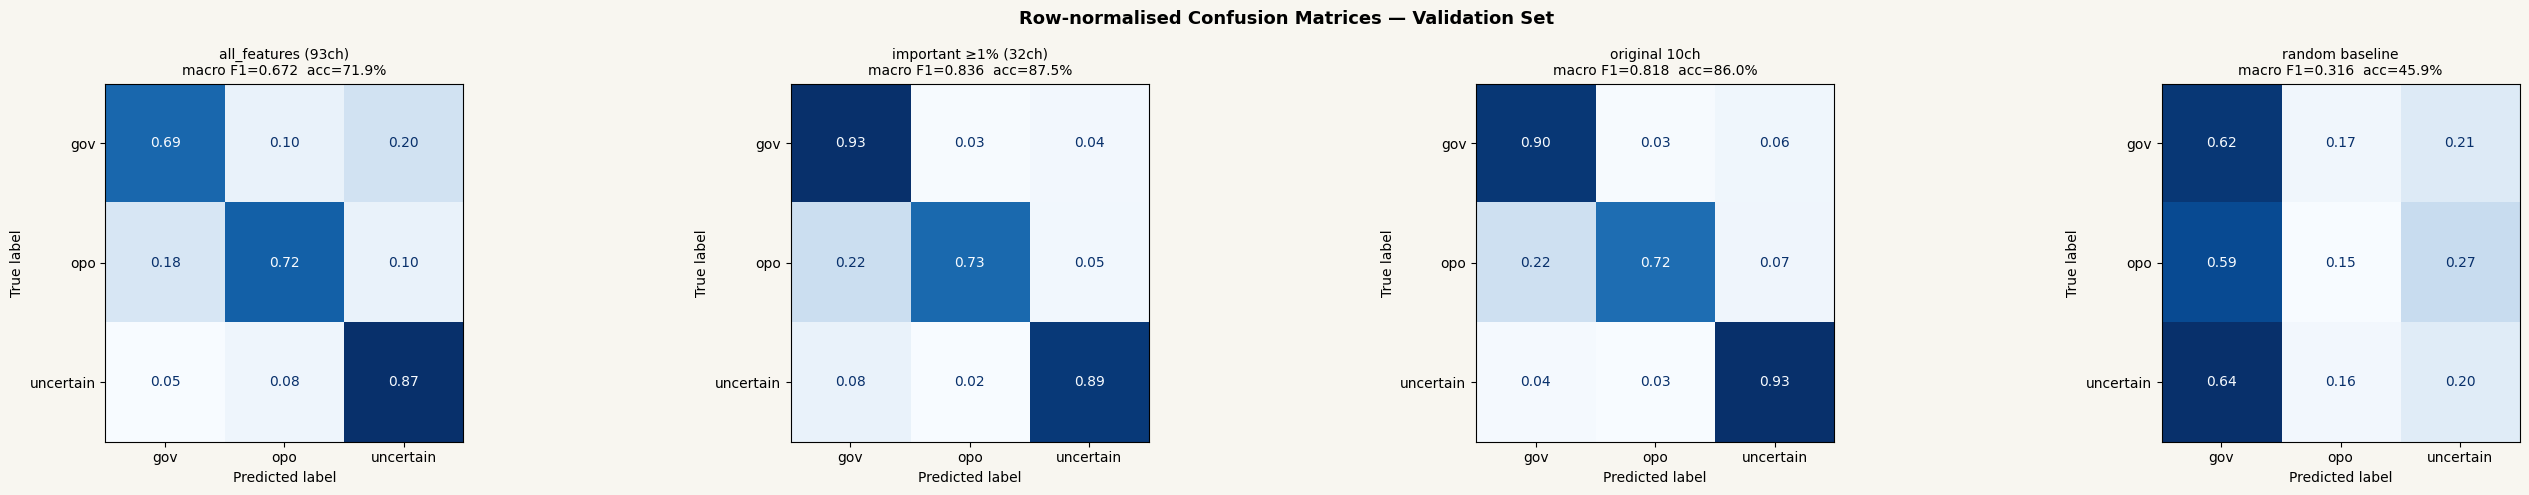

Confusion matrix panel saved.


In [174]:

# ── Confusion matrices — one panel per variant ────────────────────────────────
n_variants = len(results)
fig, axes  = plt.subplots(1, n_variants, figsize=(7 * n_variants, 5), facecolor='#F8F6F0')
if n_variants == 1:
    axes = [axes]
fig.suptitle('Row-normalised Confusion Matrices — Validation Set', fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    mf1 = r['report']['macro avg']['f1-score']
    acc = r['acc']
    ConfusionMatrixDisplay(r['cm_norm'], display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
    ax.set_title(f'{name}\nmacro F1={mf1:.3f}  acc={acc:.1%}', fontsize=10)
    ax.set_facecolor('#F8F6F0')

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix panel saved.')


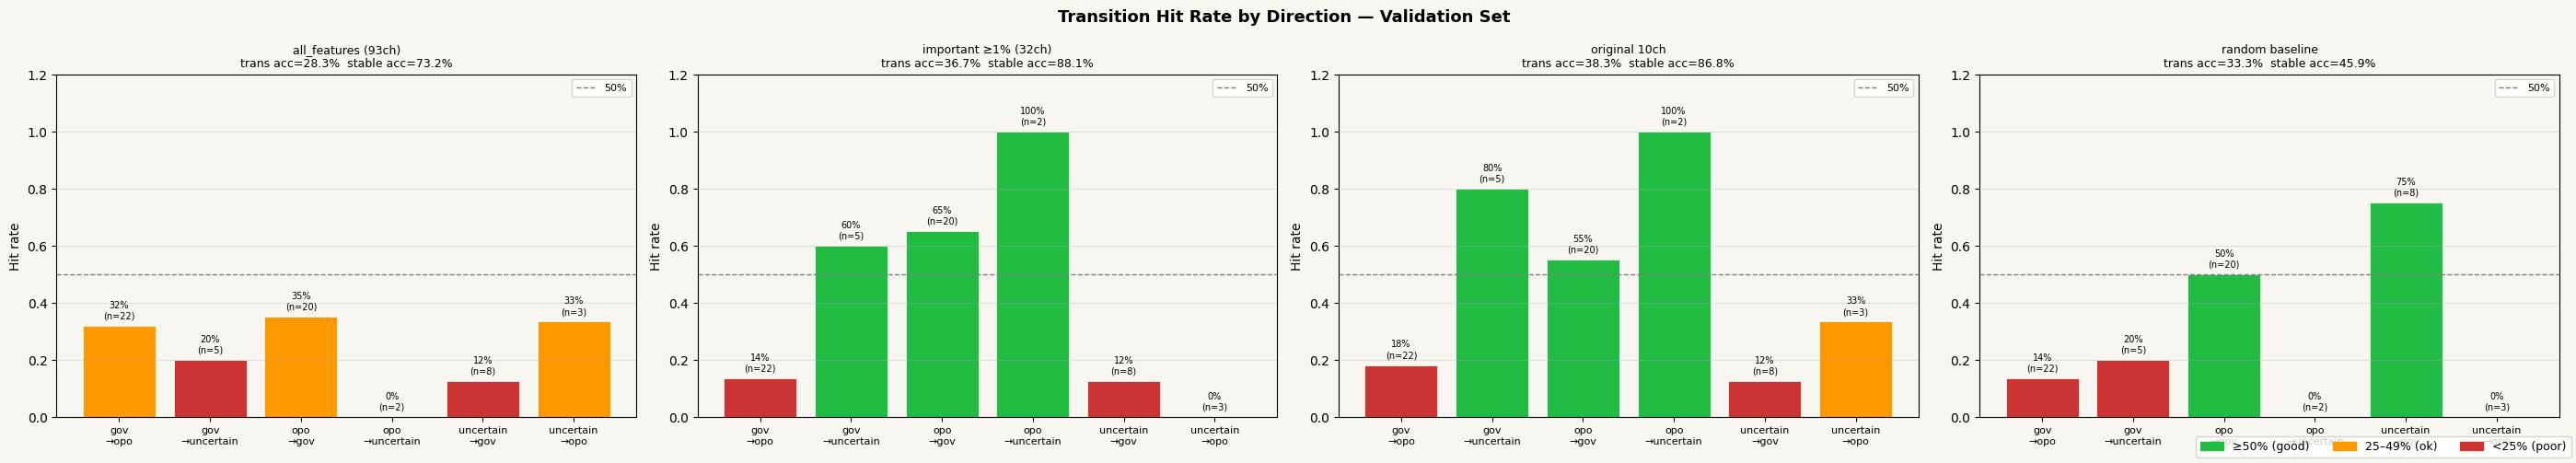

Transition comparison saved.

COMPLETE.


In [175]:

# ── Transition hit-rate comparison ────────────────────────────────────────────
directions   = [(f, t) for f in CLASS_NAMES for t in CLASS_NAMES if f != t]
n_variants   = len(results)
fig, axes    = plt.subplots(1, n_variants, figsize=(7 * n_variants, 5), facecolor='#F8F6F0')
if n_variants == 1:
    axes = [axes]
fig.suptitle('Transition Hit Rate by Direction — Validation Set', fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    tdf = r['trans_only_df']
    labels_bar, hit_rates_bar, counts_bar = [], [], []
    for from_c, to_c in directions:
        sub = tdf[(tdf['from_cls'] == from_c) & (tdf['to_cls'] == to_c)]
        if len(sub) == 0:
            continue
        labels_bar.append(f'{from_c}\n→{to_c}')
        hit_rates_bar.append(sub['hit'].mean())
        counts_bar.append(len(sub))

    x          = np.arange(len(labels_bar))
    bar_colors = ['#22BB44' if h >= 0.5 else ('#FF9900' if h >= 0.25 else '#CC3333')
                  for h in hit_rates_bar]
    bars = ax.bar(x, hit_rates_bar, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.5, color='grey', ls='--', lw=1, label='50%')
    ax.set_xticks(x); ax.set_xticklabels(labels_bar, fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Hit rate')
    ax.set_title(f'{name}\ntrans acc={r["trans_acc"]:.1%}  stable acc={r["stable_acc"]:.1%}', fontsize=9)
    ax.set_facecolor('#F8F6F0')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, h, n in zip(bars, hit_rates_bar, counts_bar):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{h:.0%}\n(n={n})', ha='center', va='bottom', fontsize=7)

patches = [
    mpatches.Patch(color='#22BB44', label='≥50% (good)'),
    mpatches.Patch(color='#FF9900', label='25–49% (ok)'),
    mpatches.Patch(color='#CC3333', label='<25% (poor)'),
]
fig.legend(handles=patches, loc='lower right', fontsize=9, ncol=3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_transitions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition comparison saved.')
print('\nCOMPLETE.')
